In [1]:
#CARGA LIBRERIAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#PROCESAMIENTO DATOS

def leer_datos_csv(ruta_csv, col_x="x", col_y="y"):
    df = pd.read_csv(ruta_csv)
    x = df[col_x].values.astype(float)
    y = df[col_y].values.astype(float)
    return x, y

def regresion_minimos_cuadrados(X, Y):
    n = len(X)
    sum_x = np.sum(X)
    sum_y = np.sum(Y)
    sum_x2 = np.sum(X**2)
    sum_xy = np.sum(X * Y)
    sum_y2 = np.sum(Y**2)

    delta = n*sum_x2 - (sum_x**2)

    B = (n*sum_xy - sum_x*sum_y) / delta
    A = (sum_x2*sum_y - sum_x*sum_xy) / delta

    Y_ajustada = A + B*X
    residuos = Y - Y_ajustada
    SSR = np.sum(residuos**2)
    sigma_y2 = SSR / (n - 2)

    sigma_A = np.sqrt(sigma_y2 * (sum_x2 / delta))
    sigma_B = np.sqrt(sigma_y2 * (n / delta))

    Y_media = np.mean(Y)
    SST = np.sum((Y - Y_media)**2)
    R2 = 1 - SSR / SST

    # === COEFICIENTE DE CORRELACIÓN r ===
    num_r = n * sum_xy - sum_x * sum_y
    den_r = np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))
    r = num_r / den_r


    return {
        "A": A, "B": B,
        "sum_x": sum_x, "sum_y": sum_y,
        "sum_x2": sum_x2, "sum_xy": sum_xy,
        "sum_y2": sum_y2, "delta": delta,
        "SSR": SSR, "sigma_y2": sigma_y2,
        "sigma_A": sigma_A, "sigma_B": sigma_B,
        "R2": R2,
        "r": r
    }

def transformar_datos(x, y, escala):
    escala = escala.lower()

    if escala == "lineal":
        return x, y, "y = A + Bx"

    elif escala == "loglog":
        return np.log(x), np.log(y), "ln(y) = A + B ln(x) → y = e^A x^B"

    elif escala == "semilogy":
        return x, np.log(y), "ln(y) = A + Bx → y = e^A e^(Bx)"

    else:
        raise ValueError("Escala inválida")

def mostrar_tabla(x, y, X, Y, res, titulo, escala):

    if escala == "lineal":
        # TABLA SIMPLIFICADA PARA LINEAL
        base = {
            "x": x,
            "y": y,
            "x^2": x**2,
            "y^2": y**2,
            "x*y": x*y
        }

    elif escala == "loglog":
        # TABLA COMPLETA PARA LOG-LOG
        base = {
            "x": x,
            "y": y,
            "X (ln x)": X,
            "Y (ln y)": Y,
            "x^2": x**2,
            "y^2": y**2,
            "x*y": x*y,
            "X^2 (ln x)^2": X**2,
            "Y^2 (ln y)^2": Y**2,
            "X*Y (ln x·ln y)": X * Y
        }

    elif escala == "semilogy":
        # TABLA COMPLETA PARA SEMILOG Y
        base = {
            "x": x,
            "y": y,
            "Y (ln y)": Y,
            "x^2": x**2,
            "y^2": y**2,
            "x*y": x*y,
            "Y^2 (ln y)^2": Y**2,
            "X*Y (x·ln y)": X * Y
        }

    else:
        raise ValueError("La escala debe ser: 'lineal', 'loglog' o 'semilogy'")

    # Construcción del DataFrame
    df = pd.DataFrame(base)

    print("\n===== TABLA:", titulo, "=====\n")
    print(df.to_string(index=False))

    print("\n----- SUMAS -----")
    print(f"ΣX   = {res['sum_x']}")
    print(f"ΣY   = {res['sum_y']}")
    print(f"ΣX²  = {res['sum_x2']}")
    print(f"ΣXY  = {res['sum_xy']}")
    print(f"ΣY²  = {res['sum_y2']}")
    print(f"Δ    = {res['delta']}")

    print("\n----- PARÁMETROS -----")
    print(f"A      = {res['A']}")
    print(f"B      = {res['B']}")
    print(f"σ_A    = {res['sigma_A']}")
    print(f"σ_B    = {res['sigma_B']}")
    print(f"σ_y²   = {res['sigma_y2']}")
    print(f"R²     = {res['R2']}")

def graficar_datos_y_recta(x, y, escala, res, titulo, modo="transformada"):
    A = res["A"]
    B = res["B"]
    x_plot = np.linspace(min(x), max(x), 200)

    # === GRAFICAR SOLO LA TRANSFORMADA ===
    if modo == "transformada":
        plt.figure()
        plt.scatter(x, y, label="Datos")

        if escala == "lineal":
            plt.plot(x_plot, A + B*x_plot, "r", label="Ajuste lineal")

        elif escala == "loglog":
            plt.plot(x_plot, np.exp(A) * x_plot**B, "r", label="Ajuste potencia")
            plt.xscale("log")
            plt.yscale("log")

        elif escala == "semilogy":
            plt.plot(x_plot, np.exp(A)*np.exp(B*x_plot), "r", label="Ajuste exponencial")
            plt.yscale("log")

        plt.title(titulo + " (transformada)")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid(True)
        plt.legend()
        plt.show()
        return   # 👈 EVITA que dibuje la normal también

    # === GRAFICAR SOLO LA DESNORMALIZADA ===
    if modo == "normal":
        plt.figure()
        plt.scatter(x, y, label="Datos originales")

        if escala == "loglog":
            y_pred = np.exp(A) * x_plot**B
            plt.plot(x_plot, y_pred, "r", label="Modelo potencia destransformado")
            plt.title(titulo + " (escala normal)")

        elif escala == "semilogy":
            y_pred = np.exp(A) * np.exp(B * x_plot)
            plt.plot(x_plot, y_pred, "r", label="Modelo exponencial destransformado")
            plt.title(titulo + " (escala normal)")

        elif escala == "lineal":
            y_pred = A + B*x_plot
            plt.plot(x_plot, y_pred, "r", label="Ajuste lineal")
            plt.title(titulo + " (escala normal)")

        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid(True)
        plt.legend()
        plt.show()

        import pandas as pd
import numpy as np

def exportar_a_excel(x, y, X, Y, res, escala, nombre_archivo):
    """
    Exporta:
    - Datos completos (x, y, x², y², xy, ln(x), ln(y))
    - Valores transformados (X, Y, X², Y², XY)
    - Sumatorias
    - Parámetros del ajuste
    - Ecuación final (transformada y destransformada)

    Todo en un SOLO archivo XLSX con varias hojas.
    """

    # ---------------------------
    # HOJA 1: DATOS
    # ---------------------------
    datos = {
        "x": x,
        "y": y,
        "x^2": x**2,
        "y^2": y**2,
        "x*y": x*y,
        "ln(x)": np.where(x>0, np.log(x), np.nan),
        "ln(y)": np.where(y>0, np.log(y), np.nan)
    }

    # Transformados (solo si corresponden)
    if escala in ["loglog", "semilogy"]:
        datos["X (transformada)"] = X
        datos["Y (transformada)"] = Y
        datos["X^2"] = X**2
        datos["Y^2"] = Y**2
        datos["X*Y"] = X * Y

    df_datos = pd.DataFrame(datos)

    # ---------------------------
    # HOJA 2: SUMATORIAS
    # ---------------------------
    df_sumatorias = pd.DataFrame({
        "Magnitud": ["ΣX", "ΣY", "ΣX²", "ΣXY", "ΣY²", "Δ"],
        "Valor": [
            res["sum_x"],
            res["sum_y"],
            res["sum_x2"],
            res["sum_xy"],
            res["sum_y2"],
            res["delta"]
        ]
    })

    # ---------------------------
    # HOJA 3: PARAMETROS
    # ---------------------------
    df_parametros = pd.DataFrame({
        "Parámetro": ["A", "B", "σA", "σB", "σy²", "r", "R²"],
        "Valor": [
            res["A"],
            res["B"],
            res["sigma_A"],
            res["sigma_B"],
            res["sigma_y2"],
            res["r"],
            res["r"]**2
        ]
    })

    # ---------------------------
    # HOJA 4: MODELO FINAL
    # ---------------------------
    if escala == "lineal":
        eq1 = f"Y = A + Bx"
        eq2 = f"y = {res['A']} + {res['B']}x"
    elif escala == "loglog":
        eq1 = "ln(y) = A + B ln(x)"
        eq2 = f"y = {np.exp(res['A'])} * x^{res['B']}"
    elif escala == "semilogy":
        eq1 = "ln(y) = A + Bx"
        eq2 = f"y = {np.exp(res['A'])} * e^{B}x"
    else:
        eq1 = "Desconocido"
        eq2 = "Desconocido"

    df_modelo = pd.DataFrame({
        "Ecuación": ["Modelo transformado", "Modelo destransformado"],
        "Expresión": [eq1, eq2]
    })

    # ---------------------------
    # EXPORTACIÓN EXCEL
    # ---------------------------
    with pd.ExcelWriter(nombre_archivo + ".xlsx") as writer:
        df_datos.to_excel(writer, sheet_name="Datos", index=False)
        df_sumatorias.to_excel(writer, sheet_name="Sumatorias", index=False)
        df_parametros.to_excel(writer, sheet_name="Parametros", index=False)
        df_modelo.to_excel(writer, sheet_name="Modelo", index=False)

    print(f"Archivo generado: {nombre_archivo}.xlsx")

#FÓRMULAS PARA MÍNIMOS CUADRADOS

##1. Determinante:
    Δ = n·Σx² − (Σx)²
    Es un valor que surge al resolver las ecuaciones normales de mínimos cuadrados. Representa “cuánta variación real hay en los valores de x”. Si Δ = 0, no se puede calcular la recta.

##2. Pendiente:
    B = (n·Σxy − Σx·Σy) / Δ
    Determina la inclinación de la recta que mejor ajusta los datos. Usa todas las sumas cruzadas xiyi y depende directamente de Δ. Es cómo cambia y por cada unidad de cambio en x.

##3. Intercepto:
    A = (Σx²·Σy − Σx·Σxy) / Δ
    Representa el valor donde la recta toca el eje Y. Se obtiene al resolver las ecuaciones normales usando las sumas de los datos. Depende de cómo están distribuidos los puntos alrededor de x=0

##4. Suma de residuos al cuadrado:
    SSR = ( Σy² − A·Σy − B·Σxy ) / (n − 2)
    Mide qué tan lejos están los datos reales de la recta ajustada. Entre más pequeño sea SSR, mejor es el ajuste. Tu profesor usa esta forma porque evita recalcular cada residuo individual.

##5. Varianza de los residuos:
    σ_y² = SSR
    Representa la “incertidumbre promedio” del ajuste. Es el error cuadrático medio entre los datos y la recta.

##6. Incertidumbre de A:
    σ_A = sqrt( σ_y² · ( Σx² / Δ ) )
    Mide cuánta variación tendría el intercepto si se repitiera el experimento.Depende de qué tanto varían los x alrededor del orige

##7. Incertidumbre de B:
    σ_B = sqrt( σ_y² · ( n / Δ ) )
    Indica la precisión de la pendiente. Entre más datos (n grande) y más variación en x (Δ grande), mejor se determina B.

##8. Coeficiente de Correlación (r)

    El coeficiente de correlación lineal r se define como:

      r =            ( n·Σ(xy) − (Σx)(Σy) )
          -----------------------------------------------
          √[ ( n·Σ(x²) − (Σx)² ) · ( n·Σ(y²) − (Σy)² ) ]





Saving lineal.csv to lineal (1).csv

===== TABLA: LINEAL =====

    x     y      x^2      y^2      x*y
0.214 0.680 0.045796 0.462400 0.145520
0.221 0.977 0.048841 0.954529 0.215917
0.233 1.461 0.054289 2.134521 0.340413
0.258 2.431 0.066564 5.909761 0.627198
0.270 2.922 0.072900 8.538084 0.788940

----- SUMAS -----
ΣX   = 1.1960000000000002
ΣY   = 8.471
ΣX²  = 0.28839000000000004
ΣXY  = 2.1179880000000004
ΣY²  = 17.999295000000004
Δ    = 0.011533999999999933

----- PARÁMETROS -----
A      = -7.81705895612982
B      = 39.76278827813447
σ_A    = 0.06410058076912872
σ_B    = 0.2669050973505481
σ_y²   = 0.00016433258193166548
R²     = 0.9998648479524851


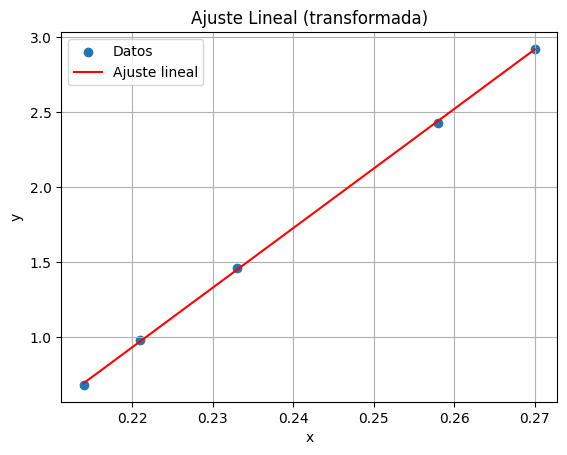


===== FUNCIÓN FINAL (LINEAL) =====
y = A + Bx
A = -7.81705895612982 ± 0.06410058076912872
B = 39.76278827813447 ± 0.2669050973505481

Función final:
y = (-7.817059 ± 0.064101) + (39.762788 ± 0.266905)·x

Coeficiente de correlación r = 0.9999324216928318
Coeficiente de determinación R² = 0.9998648479524912
Archivo generado: lineal_1.xlsx


In [8]:
# SECCION LINEAL1
# === SUBIR ARCHIVO ===
from google.colab import files
files.upload()   # selecciona lineal.csv

ruta = "lineal.csv"
x, y = leer_datos_csv(ruta)

X, Y, modelo = transformar_datos(x, y, "lineal")
res = regresion_minimos_cuadrados(X, Y)

mostrar_tabla(x, y, X, Y, res, "LINEAL", "lineal")
graficar_datos_y_recta(x, y, "lineal", res, "Ajuste Lineal")

# === FUNCIÓN FINAL CON INCERTIDUMBRES ===
A = res["A"]
B = res["B"]
sA = res["sigma_A"]
sB = res["sigma_B"]

print("\n===== FUNCIÓN FINAL (LINEAL) =====")
print(f"y = A + Bx")
print(f"A = {A} ± {sA}")
print(f"B = {B} ± {sB}")
print(f"\nFunción final:")
print(f"y = ({A:.6f} ± {sA:.6f}) + ({B:.6f} ± {sB:.6f})·x")
print(f"\nCoeficiente de correlación r = {res['r']}")
print(f"Coeficiente de determinación R² = {res['r']**2}")

exportar_a_excel(x, y, X, Y, res, "lineal", "lineal_1")

Saving lineal2.csv to lineal2.csv

===== TABLA: LINEAL =====

   x     y    x^2      y^2     x*y
0.30 1.090 0.0900 1.188100 0.32700
0.35 1.174 0.1225 1.378276 0.41090
0.40 1.237 0.1600 1.530169 0.49480
0.45 1.327 0.2025 1.760929 0.59715
0.50 1.406 0.2500 1.976836 0.70300
0.55 1.475 0.3025 2.175625 0.81125
0.60 1.530 0.3600 2.340900 0.91800
0.65 1.595 0.4225 2.544025 1.03675
0.70 1.645 0.4900 2.706025 1.15150
0.75 1.671 0.5625 2.792241 1.25325
0.80 1.758 0.6400 3.090564 1.40640

----- SUMAS -----
ΣX   = 6.05
ΣY   = 15.907999999999998
ΣX²  = 3.6025
ΣXY  = 9.11
ΣY²  = 23.48369
Δ    = 3.0249999999999986

----- PARÁMETROS -----
A      = 0.7249818181818157
B      = 1.3112727272727325
σ_A    = 0.025682492348351623
σ_B    = 0.044877795499841756
σ_y²   = 0.0005538545454545445
R²     = 0.9895680582999723


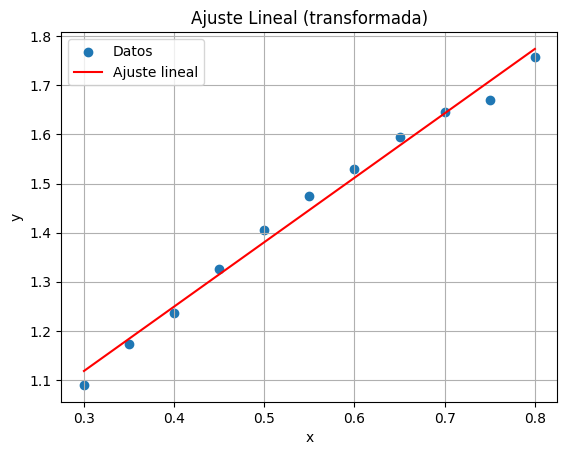


===== FUNCIÓN FINAL (LINEAL) =====
y = A + Bx
A = 0.7249818181818157 ± 0.025682492348351623
B = 1.3112727272727325 ± 0.044877795499841756

Función final:
y = (0.724982 ± 0.025682) + (1.311273 ± 0.044878)·x

Coeficiente de correlación r = 0.9947703545542408
Coeficiente de determinación R² = 0.98956805829997
Archivo generado: lineal_1.xlsx


In [4]:
# SECCION LINEAL2
# === SUBIR ARCHIVO ===
from google.colab import files
files.upload()   # selecciona lineal.csv

ruta = "lineal2.csv"
x, y = leer_datos_csv(ruta)

X, Y, modelo = transformar_datos(x, y, "lineal")
res = regresion_minimos_cuadrados(X, Y)

mostrar_tabla(x, y, X, Y, res, "LINEAL", "lineal")
graficar_datos_y_recta(x, y, "lineal", res, "Ajuste Lineal")

# === FUNCIÓN FINAL CON INCERTIDUMBRES ===
A = res["A"]
B = res["B"]
sA = res["sigma_A"]
sB = res["sigma_B"]

print("\n===== FUNCIÓN FINAL (LINEAL) =====")
print(f"y = A + Bx")
print(f"A = {A} ± {sA}")
print(f"B = {B} ± {sB}")
print(f"\nFunción final:")
print(f"y = ({A:.6f} ± {sA:.6f}) + ({B:.6f} ± {sB:.6f})·x")
print(f"\nCoeficiente de correlación r = {res['r']}")
print(f"Coeficiente de determinación R² = {res['r']**2}")

exportar_a_excel(x, y, X, Y, res, "lineal", "lineal_1")

Saving log_log.csv to log_log (1).csv

===== TABLA: LOG-LOG =====

  x      y  X (ln x)  Y (ln y)  x^2         y^2     x*y  X^2 (ln x)^2  Y^2 (ln y)^2  X*Y (ln x·ln y)
0.2  0.024 -1.609438 -3.729701 0.04    0.000576  0.0048      2.590290     13.910673         6.002723
0.4  0.192 -0.916291 -1.650260 0.16    0.036864  0.0768      0.839589      2.723358         1.512118
0.6  0.648 -0.510826 -0.433865 0.36    0.419904  0.3888      0.260943      0.188238         0.221629
0.8  1.536 -0.223144  0.429182 0.64    2.359296  1.2288      0.049793      0.184197        -0.095769
1.2  5.184  0.182322  1.645577 1.44   26.873856  6.2208      0.033241      2.707924         0.300024
1.4  8.232  0.336472  2.108029 1.96   67.765824 11.5248      0.113214      4.443786         0.709293
1.6 12.288  0.470004  2.508623 2.56  150.994944 19.6608      0.220903      6.293190         1.179062
1.8 17.492  0.587787  2.861744 3.24  305.970064 31.4856      0.345493      8.189577         1.682095
2.0 24.000  0.693147  3.

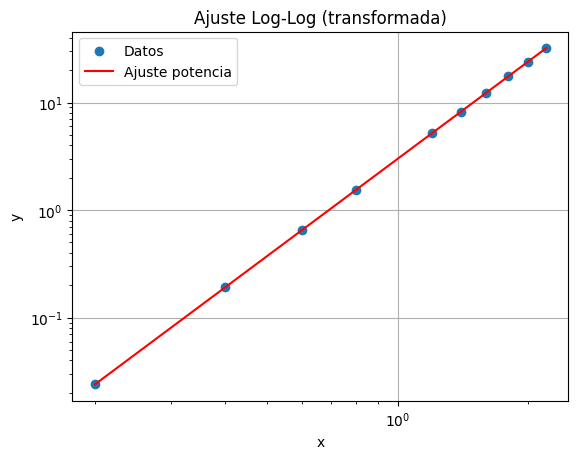

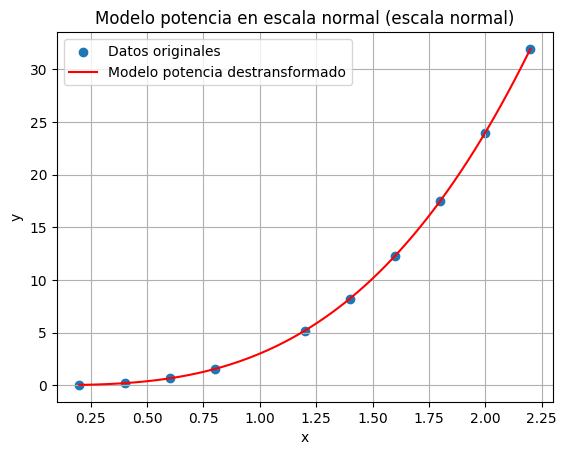


===== FUNCIÓN FINAL (LOG-LOG) =====
ln(y) = A + B ln(x)
A = 1.0985889191260685 ± 2.3346303454624228e-05
B = 2.9999749609603668 ± 3.1322271966480026e-05

Función destransformada:
y = e^A · x^B
y = 2.999930 · x^2.999975

Con incertidumbres:
e^A = 2.999930 ± 0.000070
B   = 2.999975 ± 0.000031

Coeficiente de correlación r = 0.999999999563955
Coeficiente de determinación R² = 0.99999999912791
Archivo generado: potencia_1.xlsx


In [9]:
#SECCION LOG-LOG
# === SUBIR ARCHIVO ===
from google.colab import files
files.upload()   # selecciona loglog.csv

ruta = "log_log.csv"
x, y = leer_datos_csv(ruta)

X, Y, modelo = transformar_datos(x, y, "loglog")
res = regresion_minimos_cuadrados(X, Y)

mostrar_tabla(x, y, X, Y, res, "LOG-LOG", "loglog")
graficar_datos_y_recta(x, y, "loglog", res, "Ajuste Log-Log", modo="transformada")
graficar_datos_y_recta(x, y, "loglog", res, "Modelo potencia en escala normal", modo="normal")

# === FUNCIÓN FINAL CON INCERTIDUMBRES (LOG-LOG) ===
A = res["A"]
B = res["B"]
sA = res["sigma_A"]
sB = res["sigma_B"]

print("\n===== FUNCIÓN FINAL (LOG-LOG) =====")
print("ln(y) = A + B ln(x)")
print(f"A = {A} ± {sA}")
print(f"B = {B} ± {sB}")

# Modelo destransformado:
k = np.exp(A)
sk = np.exp(A) * sA   # Propagación lineal de incertidumbre del log a k

print("\nFunción destransformada:")
print(f"y = e^A · x^B")
print(f"y = {k:.6f} · x^{B:.6f}")

print("\nCon incertidumbres:")
print(f"e^A = {k:.6f} ± {sk:.6f}")
print(f"B   = {B:.6f} ± {sB:.6f}")

print(f"\nCoeficiente de correlación r = {res['r']}")
print(f"Coeficiente de determinación R² = {res['r']**2}")

exportar_a_excel(x, y, X, Y, res, "loglog", "potencia_1")

Saving log_log2.csv to log_log2.csv

===== TABLA: LOG-LOG =====

    x    y  X (ln x)  Y (ln y)      x^2     y^2     x*y  X^2 (ln x)^2  Y^2 (ln y)^2  X*Y (ln x·ln y)
0.033 1.08 -3.411248  0.076961 0.001089  1.1664 0.03564     11.636611      0.005923        -0.262533
0.067 1.50 -2.703063  0.405465 0.004489  2.2500 0.10050      7.306548      0.164402        -1.095998
0.100 1.64 -2.302585  0.494696 0.010000  2.6896 0.16400      5.301898      0.244724        -1.139080
0.133 1.96 -2.017406  0.672944 0.017689  3.8416 0.26068      4.069928      0.452854        -1.357602
0.167 2.34 -1.789761  0.850151 0.027889  5.4756 0.39078      3.203246      0.722757        -1.521567
0.200 2.66 -1.609438  0.978326 0.040000  7.0756 0.53200      2.590290      0.957122        -1.574555
0.233 3.11 -1.456717  1.134623 0.054289  9.6721 0.72463      2.122024      1.287369        -1.652824
0.267 3.48 -1.320507  1.247032 0.071289 12.1104 0.92916      1.743738      1.555090        -1.646714
0.300 3.66 -1.203973  1.29

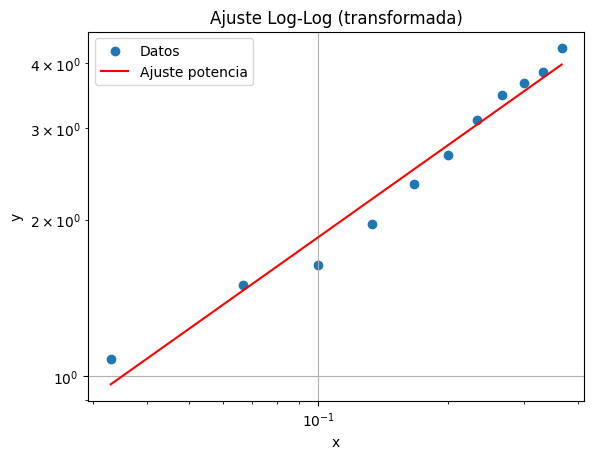

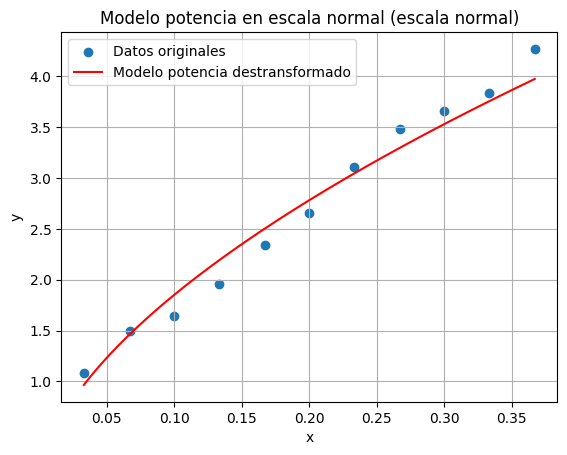


===== FUNCIÓN FINAL (LOG-LOG) =====
ln(y) = A + B ln(x)
A = 1.9688570887303094 ± 0.06559479629203385
B = 0.5875811584922516 ± 0.03371490798143487

Función destransformada:
y = e^A · x^B
y = 7.162486 · x^0.587581

Con incertidumbres:
e^A = 7.162486 ± 0.469822
B   = 0.587581 ± 0.033715

Coeficiente de correlación r = 0.9855056790591268
Coeficiente de determinación R² = 0.9712214434577906
Archivo generado: potencia_1.xlsx


In [6]:
#SECCION LOG-LOG2
# === SUBIR ARCHIVO ===
from google.colab import files
files.upload()   # selecciona loglog.csv

ruta = "log_log2.csv"
x, y = leer_datos_csv(ruta)

X, Y, modelo = transformar_datos(x, y, "loglog")
res = regresion_minimos_cuadrados(X, Y)

mostrar_tabla(x, y, X, Y, res, "LOG-LOG", "loglog")
graficar_datos_y_recta(x, y, "loglog", res, "Ajuste Log-Log", modo="transformada")
graficar_datos_y_recta(x, y, "loglog", res, "Modelo potencia en escala normal", modo="normal")

# === FUNCIÓN FINAL CON INCERTIDUMBRES (LOG-LOG) ===
A = res["A"]
B = res["B"]
sA = res["sigma_A"]
sB = res["sigma_B"]

print("\n===== FUNCIÓN FINAL (LOG-LOG) =====")
print("ln(y) = A + B ln(x)")
print(f"A = {A} ± {sA}")
print(f"B = {B} ± {sB}")

# Modelo destransformado:
k = np.exp(A)
sk = np.exp(A) * sA   # Propagación lineal de incertidumbre del log a k

print("\nFunción destransformada:")
print(f"y = e^A · x^B")
print(f"y = {k:.6f} · x^{B:.6f}")

print("\nCon incertidumbres:")
print(f"e^A = {k:.6f} ± {sk:.6f}")
print(f"B   = {B:.6f} ± {sB:.6f}")

print(f"\nCoeficiente de correlación r = {res['r']}")
print(f"Coeficiente de determinación R² = {res['r']**2}")

exportar_a_excel(x, y, X, Y, res, "loglog", "potencia_1")

Saving semilog.csv to semilog.csv

===== TABLA: SEMILOG Y =====

   x        y  Y (ln y)  x^2          y^2       x*y  Y^2 (ln y)^2  X*Y (x·ln y)
-0.6     0.17 -1.771957 0.36 2.890000e-02    -0.102      3.139831      1.063174
-0.9     0.05 -2.995732 0.81 2.500000e-03    -0.045      8.974412      2.696159
 0.2     3.57  1.272566 0.04 1.274490e+01     0.714      1.619423      0.254513
 0.5    11.16  2.412336 0.25 1.245456e+02     5.580      5.819365      1.206168
 0.8    34.91  3.552773 0.64 1.218708e+03    27.928     12.622198      2.842219
 1.1   109.16  4.692815 1.21 1.191591e+04   120.076     22.022510      5.162096
 1.4   341.32  5.832820 1.96 1.164993e+05   477.848     34.021794      8.165949
 1.7  1067.23  6.972822 2.89 1.138980e+06  1814.291     48.620244     11.853797
 2.0  3336.99  8.112824 4.00 1.113550e+07  6673.980     65.817921     16.225649
 2.3 10433.98  9.252823 5.29 1.088679e+08 23998.154     85.614735     21.281493

----- SUMAS -----
ΣX   = 8.5
ΣY   = 37.33409024240842


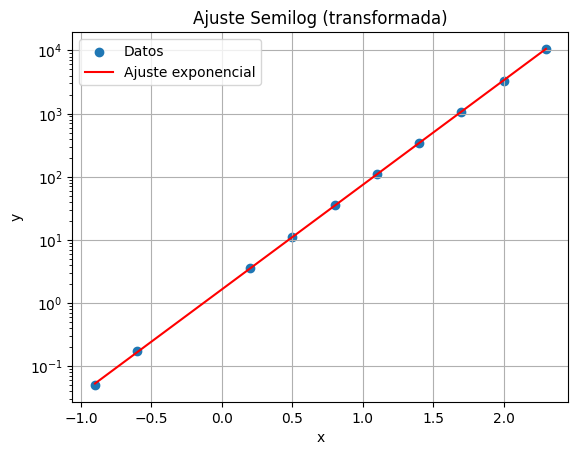

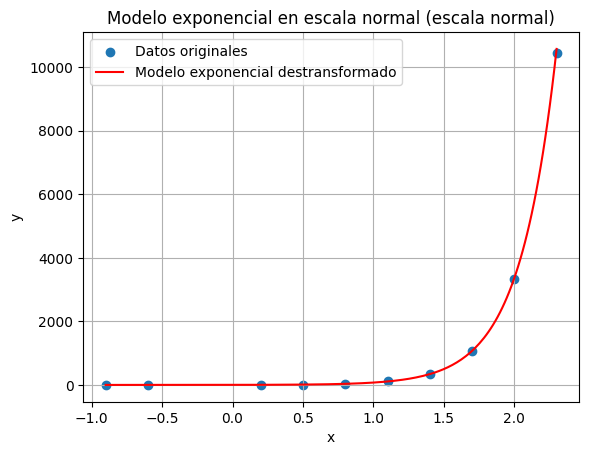


===== FUNCIÓN FINAL (SEMILOG Y) =====
ln(y) = A + Bx
A = 0.48992207600610677 ± 0.009693466240586297
B = 3.8158669979232185 ± 0.007338062162993561

Función destransformada:
y = e^A · e^(Bx)
y = 1.632189 · e^(3.815867 x)

Con incertidumbres:
e^A = 1.632189 ± 0.015822
B   = 3.815867 ± 0.007338

Coeficiente de correlación r = 0.999985208007765
Coeficiente de determinación R² = 0.9999704162343331
Archivo generado: exponencial.xlsx


/tmp/ipython-input-3338301788.py:211: RuntimeWarning: invalid value encountered in log
  "ln(x)": np.where(x>0, np.log(x), np.nan),


In [7]:
# SECCION SEMILOG
# === SUBIR ARCHIVO ===
from google.colab import files
files.upload()   # selecciona semilog.csv

ruta = "semilog.csv"
x, y = leer_datos_csv(ruta)

X, Y, modelo = transformar_datos(x, y, "semilogy")
res = regresion_minimos_cuadrados(X, Y)

mostrar_tabla(x, y, X, Y, res, "SEMILOG Y", "semilogy")
graficar_datos_y_recta(x, y, "semilogy", res, "Ajuste Semilog", modo="transformada")
graficar_datos_y_recta(x, y, "semilogy", res, "Modelo exponencial en escala normal", modo="normal")

# === FUNCIÓN FINAL CON INCERTIDUMBRES (SEMILOG Y) ===
A = res["A"]
B = res["B"]
sA = res["sigma_A"]
sB = res["sigma_B"]

print("\n===== FUNCIÓN FINAL (SEMILOG Y) =====")
print("ln(y) = A + Bx")
print(f"A = {A} ± {sA}")
print(f"B = {B} ± {sB}")

# Modelo destransformado:
k = np.exp(A)
sk = np.exp(A) * sA

print("\nFunción destransformada:")
print(f"y = e^A · e^(Bx)")
print(f"y = {k:.6f} · e^({B:.6f} x)")

print("\nCon incertidumbres:")
print(f"e^A = {k:.6f} ± {sk:.6f}")
print(f"B   = {B:.6f} ± {sB:.6f}")

print(f"\nCoeficiente de correlación r = {res['r']}")
print(f"Coeficiente de determinación R² = {res['r']**2}")

exportar_a_excel(x, y, X, Y, res, "semilogy", "exponencial")